# 02 — OCR Engine Evaluation: Tesseract vs EasyOCR

This notebook benchmarks the two open-source OCR engines on a stratified sample
of the raw PDF dataset. For each sampled page it measures:

| Metric | Method |
|--------|--------|
| **Processing time** | wall-clock seconds per page |
| **Word count** | proxy for extraction coverage |
| **Confidence** | Tesseract word-level mean; EasyOCR text-detection score |
| **CER** (Character Error Rate) | only for PDFs with an embedded text layer (used as reference) |

Results are saved incrementally to `../../data/ocr_eval/results.csv`
so the notebook can be interrupted and resumed safely.

## Setup

In [1]:
import sys
from pathlib import Path

SRC_DIR = Path("../src/assets").resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Source path:", SRC_DIR)

Source path: /home/ludrian/projects/magisterka/page-stream-segmentation/src/assets


In [2]:
import csv
import random
from collections import defaultdict
from pathlib import Path

import fitz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

from services.pdf_loader import PdfLoader
from services.tesseract_ocr import TesseractOcr
from services.easyocr_ocr import EasyOcrEngine

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
})
print("Imports OK")

Imports OK


## Configuration

In [3]:
RAW_DATA_PATH = "../../data/raw_data"
ASSETS_PATH   = Path("../../data/assets")
EVAL_OUT_DIR  = Path("../../data/ocr_eval")
CHART_DIR     = EVAL_OUT_DIR / "charts"

EVAL_OUT_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(exist_ok=True)

# Number of documents sampled per document type
DOCS_PER_TYPE = 3    # increase to 5–10 for more robust estimates
PAGES_PER_DOC = 3    # max pages evaluated per document
IMAGE_DPI     = 200
RANDOM_SEED   = 42

EASYOCR_GPU = True   # set False if CUDA is unavailable

print(f"Docs per type : {DOCS_PER_TYPE}")
print(f"Pages per doc : {PAGES_PER_DOC}")
print(f"Output        : {EVAL_OUT_DIR.resolve()}")

Docs per type : 3
Pages per doc : 3
Output        : /home/ludrian/projects/magisterka/data/ocr_eval


## Build stratified sample

In [4]:
random.seed(RANDOM_SEED)

loader   = PdfLoader(raw_data_path=RAW_DATA_PATH)
all_docs = loader.get_all_documents()

by_type = defaultdict(list)
for d in all_docs:
    by_type[d.doc_type].append(d)

sample_docs = []
for dtype, docs in sorted(by_type.items()):
    chosen = random.sample(docs, min(DOCS_PER_TYPE, len(docs)))
    sample_docs.extend(chosen)
    print(f"  {dtype:<30} sampled {len(chosen)}/{len(docs)}")

print(f"\nTotal sample: {len(sample_docs)} documents")

2026-06-06 22:35:21.868 | WARNING  | services.pdf_loader:get_all_documents:100 - Skipping invalid PDF ../../data/raw_data/questionnaire/21939-sotomayor-s-senate-questionnaire.pdf: TOO_LARGE (306.3MB)
2026-06-06 22:35:28.028 | WARNING  | services.pdf_loader:get_all_documents:100 - Skipping invalid PDF ../../data/raw_data/form/21884855-dos-22-04-051.pdf: ZERO_SIZE
2026-06-06 22:35:28.457 | INFO     | services.pdf_loader:get_all_documents:112 - Loaded 996 valid documents


  budget                         sampled 3/58
  email                          sampled 3/32
  form                           sampled 3/67
  handwritten                    sampled 3/172
  invoice                        sampled 3/57
  language                       sampled 3/7
  letter                         sampled 3/149
  memo                           sampled 3/47
  news article                   sampled 3/84
  questionnaire                  sampled 3/39
  resume                         sampled 3/183
  scientific publication         sampled 3/39
  specification                  sampled 3/62

Total sample: 39 documents


## Helper functions

**CER (Character Error Rate)** is computed only when the PDF has an embedded
text layer. PyMuPDF's `get_text()` output serves as the reference transcript.

In [5]:
def levenshtein_distance(s1: str, s2: str) -> int:
    """Compute Levenshtein edit distance between two strings."""
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)
    if not s2:
        return len(s1)
    prev = list(range(len(s2) + 1))
    for i, c1 in enumerate(s1):
        curr = [i + 1]
        for j, c2 in enumerate(s2):
            curr.append(min(prev[j + 1] + 1, curr[j] + 1, prev[j] + (c1 != c2)))
        prev = curr
    return prev[-1]


def compute_cer(reference: str, hypothesis: str) -> float:
    """Character Error Rate. Returns -1.0 if reference is empty."""
    ref = reference.strip()
    hyp = hypothesis.strip()
    if not ref:
        return -1.0
    return round(levenshtein_distance(ref, hyp) / len(ref), 4)


def pdf_embedded_text(pdf_path: str, page_idx: int) -> str:
    """Extract embedded text from a PDF page (empty string for pure scans)."""
    doc = fitz.open(pdf_path)
    try:
        return doc[page_idx].get_text("text").strip()
    finally:
        doc.close()


def render_page(pdf_path: str, page_idx: int, dpi: int = 200) -> Image.Image:
    """Render a single PDF page to a PIL Image."""
    doc = fitz.open(pdf_path)
    try:
        pix = doc[page_idx].get_pixmap(dpi=dpi)
        return Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
    finally:
        doc.close()

print("Helpers defined")

Helpers defined


## Initialise OCR engines

In [6]:
tesseract = TesseractOcr(lang="eng", dpi=IMAGE_DPI)
easyocr_e = EasyOcrEngine(langs=["en"], gpu=EASYOCR_GPU)

engines = [tesseract, easyocr_e]
print(f"Engines: {[e.name for e in engines]}")

2026-06-06 22:35:28.604 | INFO     | services.tesseract_ocr:_verify_installation:39 - Tesseract version: 5.3.4


Engines: ['tesseract', 'easyocr']


## Run benchmark

Results are appended to `results.csv` after each page — safe to interrupt and resume.

In [7]:
RESULTS_CSV = EVAL_OUT_DIR / "results.csv"
FIELDNAMES  = [
    "doc_type", "doc_name", "page_idx",
    "engine", "elapsed_s", "word_count", "confidence", "cer",
    "has_embedded_text",
]

done_set = set()
if RESULTS_CSV.exists():
    prev = pd.read_csv(RESULTS_CSV)
    for _, row in prev.iterrows():
        done_set.add((row["doc_name"], int(row["page_idx"]), row["engine"]))
    print(f"Resuming — {len(done_set)} measurements already recorded")

write_header = not RESULTS_CSV.exists() or RESULTS_CSV.stat().st_size == 0
csv_file = open(RESULTS_CSV, "a", newline="", encoding="utf-8")
writer   = csv.DictWriter(csv_file, fieldnames=FIELDNAMES)
if write_header:
    writer.writeheader()

try:
    for doc in tqdm(sample_docs, desc="Documents"):
        n_pages = min(doc.page_count, PAGES_PER_DOC)

        for page_idx in range(n_pages):
            embedded_text = pdf_embedded_text(doc.absolute_filepath, page_idx)
            has_embedded  = len(embedded_text) > 50
            image         = render_page(doc.absolute_filepath, page_idx, IMAGE_DPI)

            for engine in engines:
                key = (doc.doc_name, page_idx, engine.name)
                if key in done_set:
                    continue

                result = engine.extract_page(image)
                cer    = compute_cer(embedded_text, result.text) if has_embedded else -1.0

                writer.writerow({
                    "doc_type":          doc.doc_type,
                    "doc_name":          doc.doc_name,
                    "page_idx":          page_idx,
                    "engine":            engine.name,
                    "elapsed_s":         round(result.elapsed_seconds, 4),
                    "word_count":        result.word_count,
                    "confidence":        result.confidence,
                    "cer":               cer,
                    "has_embedded_text": has_embedded,
                })
                csv_file.flush()
                done_set.add(key)
finally:
    csv_file.close()

print(f"\nResults saved to: {RESULTS_CSV}")

Documents:   0%|          | 0/39 [00:00<?, ?it/s]

2026-06-06 22:35:36.922 | INFO     | services.easyocr_ocr:_get_reader:52 - Initialising EasyOCR reader (langs=['en'], gpu=True) — first call may take a moment
2026-06-06 22:35:39.912 | INFO     | services.easyocr_ocr:_get_reader:57 - EasyOCR reader ready


MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree


Results saved to: ../../data/ocr_eval/results.csv


## Load results

In [8]:
df = pd.read_csv(RESULTS_CSV)
print(df.shape)
df.head()

(158, 9)


,doc_type,doc_name,page_idx,engine,elapsed_s,word_count,confidence,cer,has_embedded_text
0,budget,2300774-la24-budget,0,tesseract,5.0314,419,0.9161,0.1498,True
1,budget,2300774-la24-budget,0,easyocr,7.2281,395,0.7892,0.1398,True
2,budget,2705608-Available-Budget,0,tesseract,4.2221,254,0.8235,0.7543,True
3,budget,2705608-Available-Budget,0,easyocr,4.2655,258,0.8048,0.5500,True
4,budget,2705608-Available-Budget,1,tesseract,0.6874,5,0.7600,-1.0000,False


## Summary statistics

In [9]:
summary = (
    df.groupby("engine")[["elapsed_s", "word_count", "confidence"]]
    .agg(["mean", "median", "std"])
    .round(4)
)

cer_summary = (
    df[df["has_embedded_text"] & (df["cer"] >= 0)]
    .groupby("engine")["cer"]
    .agg(["mean", "median", "std"])
    .round(4)
    .rename(columns=lambda c: f"cer_{c}")
)

print("=== Core metrics ===")
display(summary)
print("\n=== CER (pages with embedded text only) ===")
display(cer_summary)

=== Core metrics ===


elapsed_s                 word_count                  confidence  \
               mean  median     std       mean median       std       mean   
engine                                                                       
easyocr      5.8495  4.5640  4.1967   286.6962  213.0  239.4063     0.7131   
tesseract    3.2336  2.6785  2.8800   289.3797  213.0  239.8484     0.8373   

                           
           median     std  
engine                     
easyocr    0.8048  0.2148  
tesseract  0.9267  0.1894


=== CER (pages with embedded text only) ===


,cer_mean,cer_median,cer_std
engine,,,
easyocr,0.6696,0.2063,2.1899
tesseract,0.5789,0.1553,2.1258


## Chart 1 — Processing time distribution

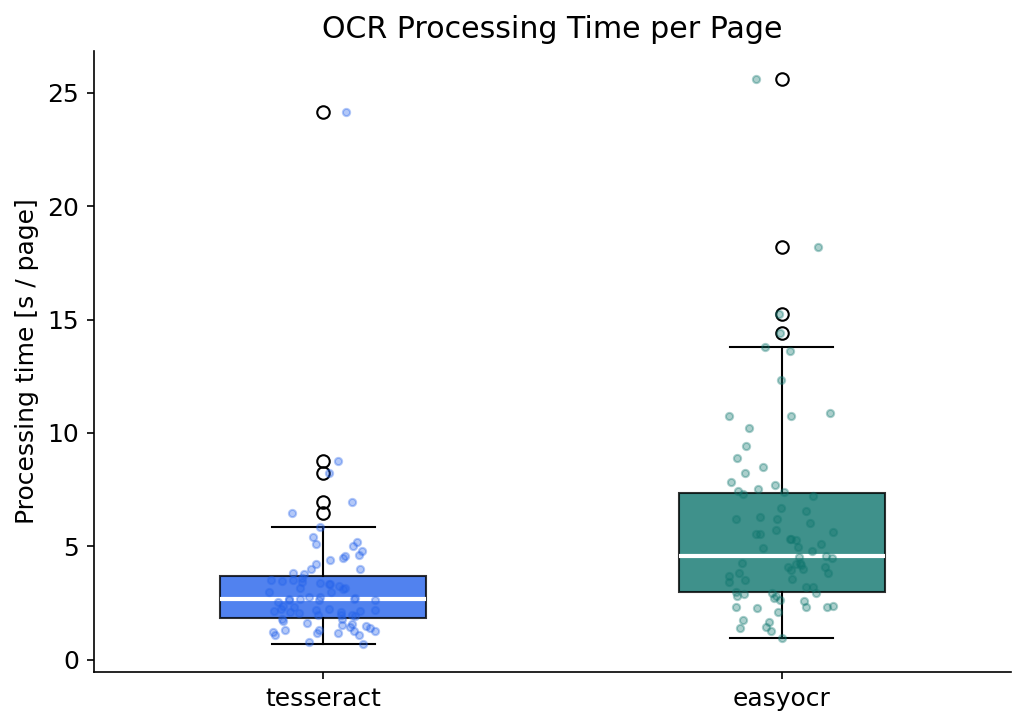

In [10]:
PALETTE = {"tesseract": "#2563EB", "easyocr": "#0F766E"}

engines_ordered = ["tesseract", "easyocr"]
data_by_engine  = [df[df["engine"] == e]["elapsed_s"].values for e in engines_ordered]
colors          = [PALETTE[e] for e in engines_ordered]

fig, ax = plt.subplots(figsize=(7, 5))

bp = ax.boxplot(
    data_by_engine,
    patch_artist=True,
    medianprops=dict(color="white", linewidth=2),
    widths=0.45,
)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

rng = np.random.default_rng(42)
for i, (data, color) in enumerate(zip(data_by_engine, colors), start=1):
    jitter = rng.uniform(-0.12, 0.12, size=len(data))
    ax.scatter(i + jitter, data, alpha=0.35, s=12, color=color, zorder=3)

ax.set_xticks([1, 2])
ax.set_xticklabels(engines_ordered)
ax.set_ylabel("Processing time [s / page]")
ax.set_title("OCR Processing Time per Page")
fig.tight_layout()
fig.savefig(CHART_DIR / "01_time_distribution.png", dpi=200)
plt.show()

## Chart 2 — Mean processing time by document type

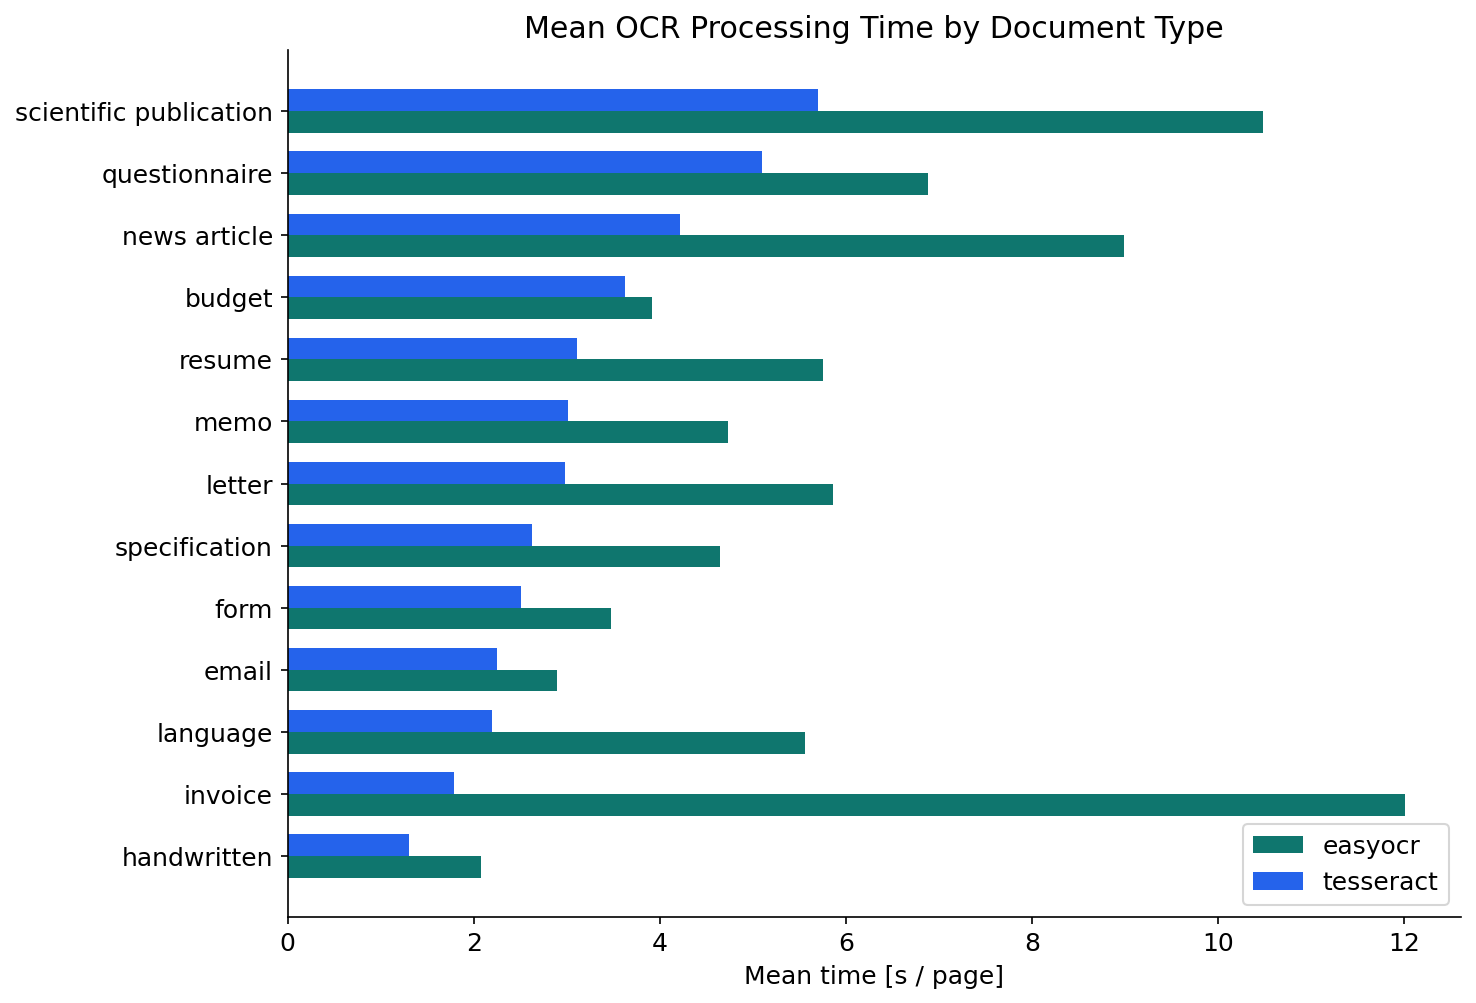

In [11]:
pivot_time = (
    df.groupby(["doc_type", "engine"])["elapsed_s"]
    .mean()
    .unstack("engine")
    .sort_values(by="tesseract", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, max(5, len(pivot_time) * 0.45 + 1)))
x, width = np.arange(len(pivot_time)), 0.35

for i, engine in enumerate(pivot_time.columns):
    ax.barh(x + i * width, pivot_time[engine], height=width,
            label=engine, color=PALETTE.get(engine, "grey"))

ax.set_yticks(x + width / 2)
ax.set_yticklabels(pivot_time.index)
ax.set_xlabel("Mean time [s / page]")
ax.set_title("Mean OCR Processing Time by Document Type")
ax.legend()
fig.tight_layout()
fig.savefig(CHART_DIR / "02_time_by_type.png", dpi=200)
plt.show()

## Chart 3 — Confidence score distribution

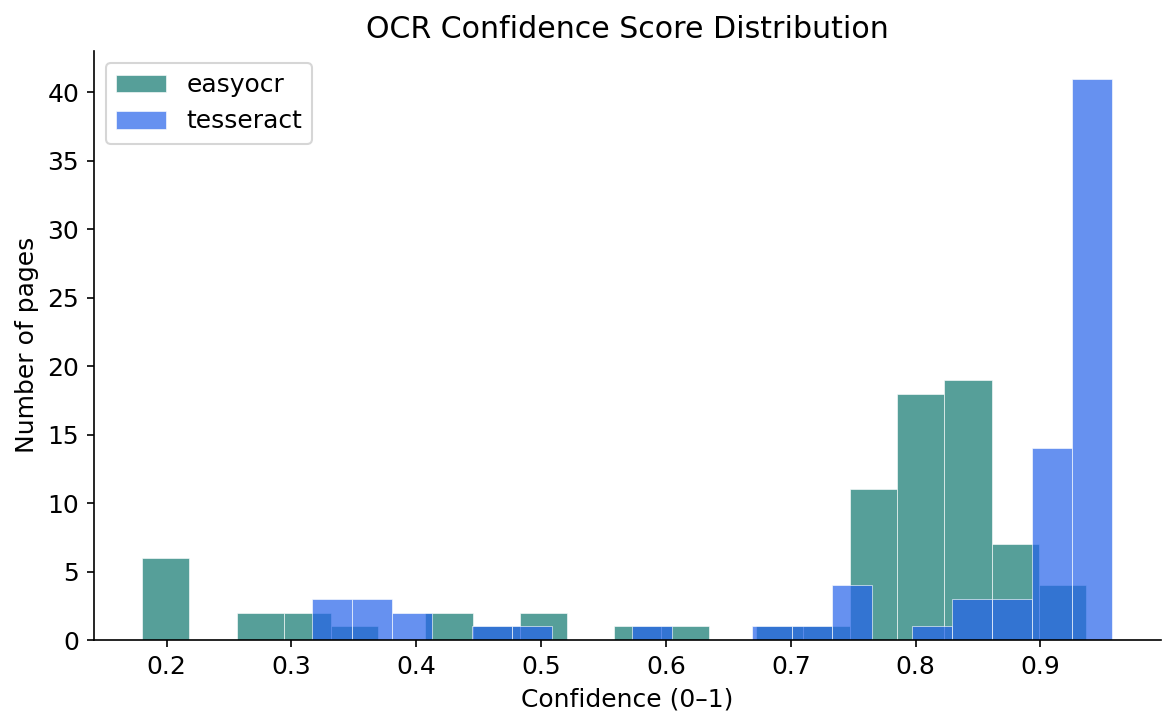

In [12]:
conf_df = df[df["confidence"] >= 0]

fig, ax = plt.subplots(figsize=(8, 5))
for engine, grp in conf_df.groupby("engine"):
    ax.hist(grp["confidence"], bins=20, alpha=0.7, label=engine,
            color=PALETTE.get(engine, "grey"), edgecolor="white", linewidth=0.4)
ax.set_xlabel("Confidence (0–1)")
ax.set_ylabel("Number of pages")
ax.set_title("OCR Confidence Score Distribution")
ax.legend()
fig.tight_layout()
fig.savefig(CHART_DIR / "03_confidence.png", dpi=200)
plt.show()

## Chart 4 — CER by document type (pages with embedded text only)

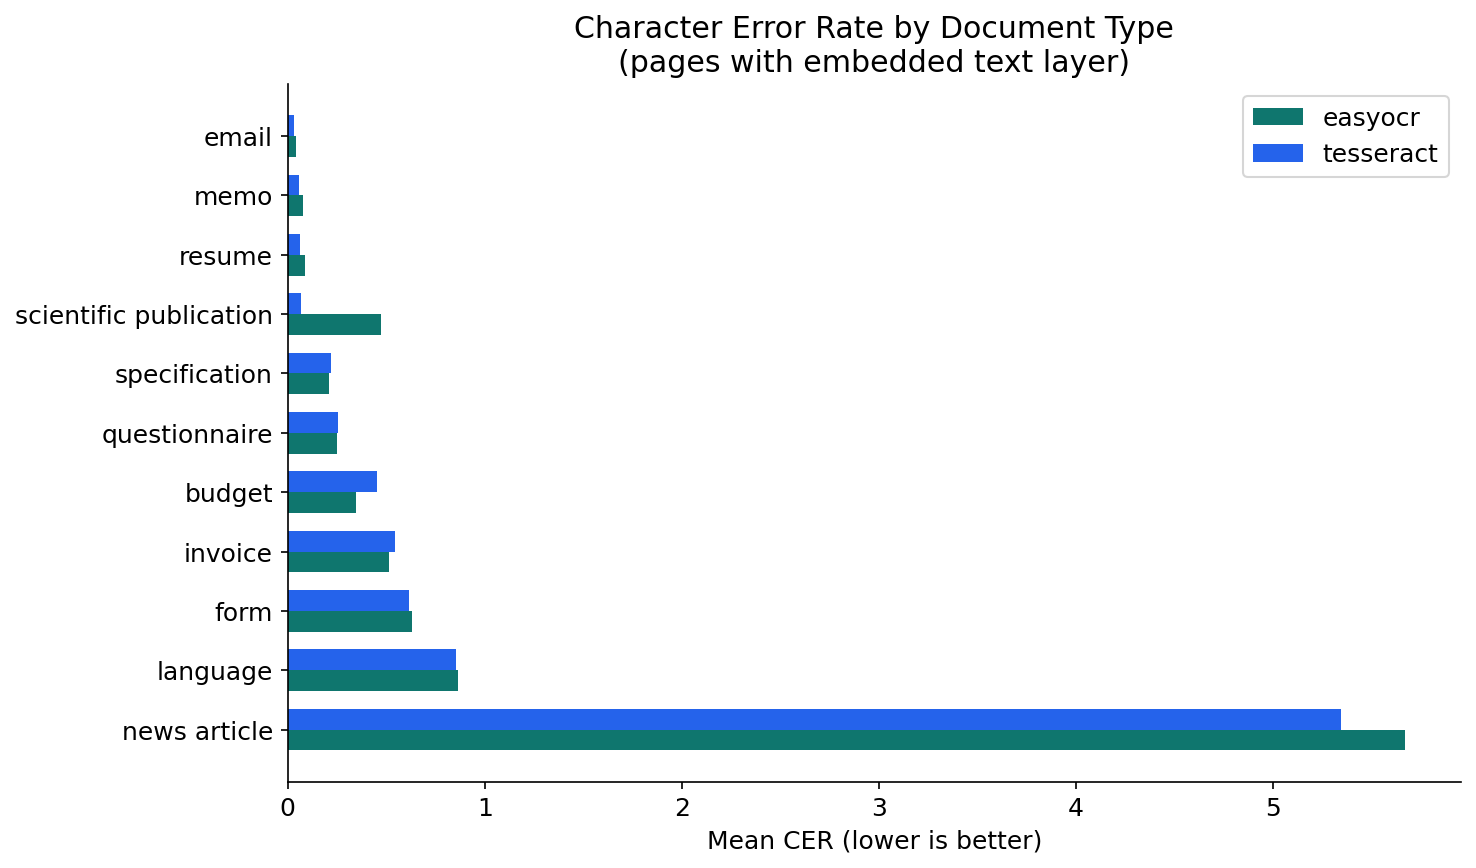

In [13]:
cer_df = df[(df["has_embedded_text"]) & (df["cer"] >= 0)]

if cer_df.empty:
    print("No pages with embedded text found — CER chart skipped.")
else:
    first_engine = cer_df["engine"].iloc[0]
    pivot_cer = (
        cer_df.groupby(["doc_type", "engine"])["cer"]
        .mean()
        .unstack("engine")
        .sort_values(by=first_engine, ascending=False)
    )

    fig, ax = plt.subplots(figsize=(10, max(5, len(pivot_cer) * 0.45 + 1)))
    x, width = np.arange(len(pivot_cer)), 0.35

    for i, engine in enumerate(pivot_cer.columns):
        ax.barh(x + i * width, pivot_cer[engine], height=width,
                label=engine, color=PALETTE.get(engine, "grey"))

    ax.set_yticks(x + width / 2)
    ax.set_yticklabels(pivot_cer.index)
    ax.set_xlabel("Mean CER (lower is better)")
    ax.set_title("Character Error Rate by Document Type\n(pages with embedded text layer)")
    ax.legend()
    fig.tight_layout()
    fig.savefig(CHART_DIR / "04_cer_by_type.png", dpi=200)
    plt.show()

## Chart 5 — Speed vs coverage scatter

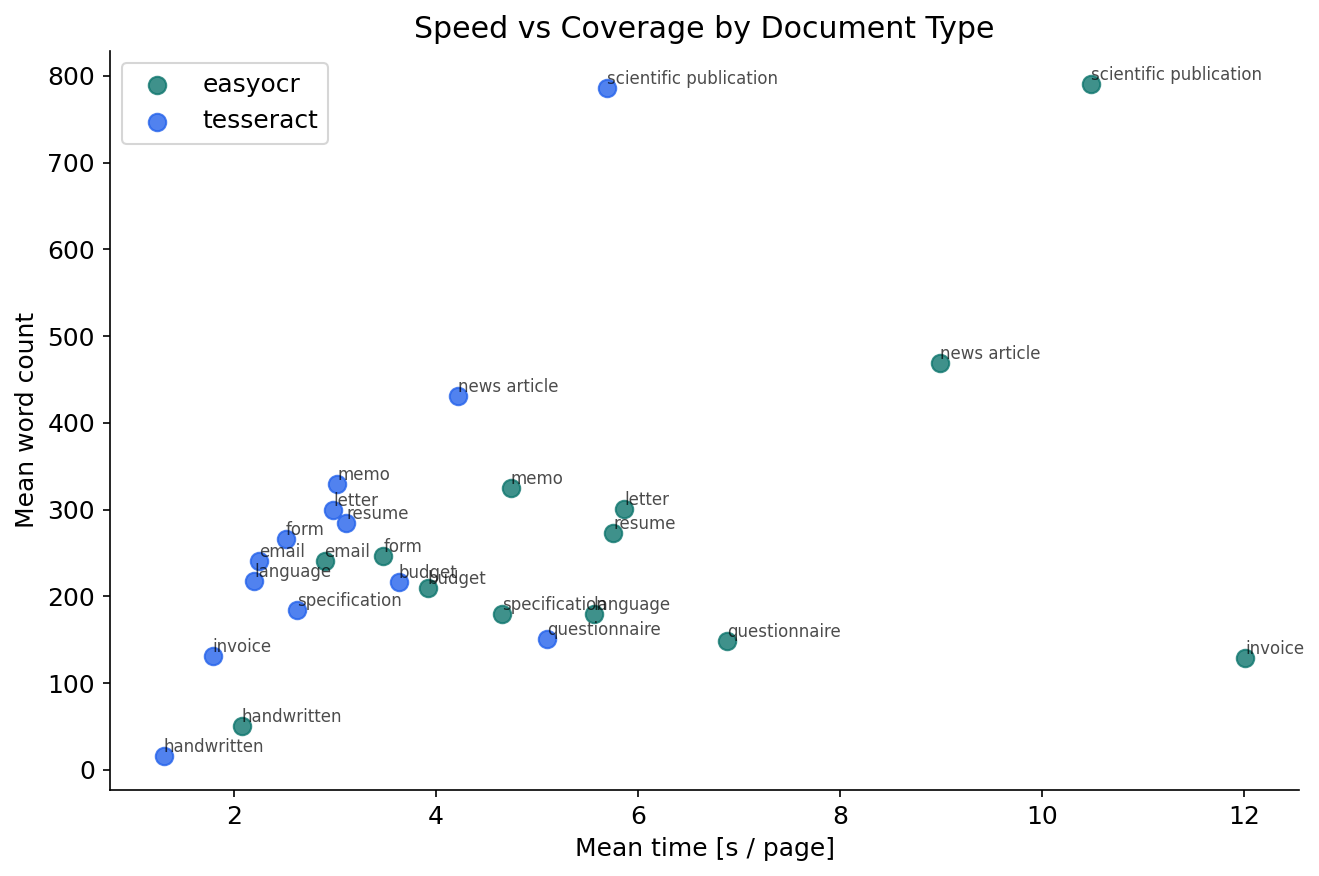

In [14]:
scatter_df = (
    df.groupby(["doc_type", "engine"])
    .agg(mean_time=("elapsed_s", "mean"), mean_words=("word_count", "mean"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 6))
for engine, grp in scatter_df.groupby("engine"):
    ax.scatter(grp["mean_time"], grp["mean_words"], label=engine,
               s=70, alpha=0.8, color=PALETTE.get(engine, "grey"))
    for _, row in grp.iterrows():
        ax.annotate(row["doc_type"], (row["mean_time"], row["mean_words"]),
                    fontsize=8, ha="left", va="bottom", alpha=0.7)

ax.set_xlabel("Mean time [s / page]")
ax.set_ylabel("Mean word count")
ax.set_title("Speed vs Coverage by Document Type")
ax.legend()
fig.tight_layout()
fig.savefig(CHART_DIR / "05_speed_vs_words.png", dpi=200)
plt.show()